# Persuasion Profiler

# Phase 1 - Synthetic Data Generation

## Tactic taxonomy


In [1]:
"""Tactic taxonomy and codebook definitions for Phase 1 synthesis.

These strings are injected into generation prompts, so wording changes here
change what the LLM produces. Edits should be reflected in LABEL_CODEBOOK.md.
"""

from __future__ import annotations

from dataclasses import dataclass
from enum import Enum


class Tactic(str, Enum):
    URGENCY_SCARCITY = "urgency_scarcity"
    FALSE_INTIMACY = "false_intimacy"
    AUTHORITY_MIMICRY = "authority_mimicry"
    GASLIGHTING_ISOLATION = "gaslighting_isolation"
    BENIGN = "benign"

    @classmethod
    def manipulative(cls) -> list["Tactic"]:
        return [t for t in cls if t is not cls.BENIGN]


@dataclass(frozen=True)
class TacticSpec:
    label: Tactic
    definition: str
    required_elements: str
    surface_cues: str
    positive_example: str
    near_miss_example: str


TACTIC_SPECS: dict[Tactic, TacticSpec] = {
    Tactic.URGENCY_SCARCITY: TacticSpec(
        label=Tactic.URGENCY_SCARCITY,
        definition=(
            "Manufactures time pressure or artificial scarcity to push the reader "
            "toward action before they can verify, compare, or consult others."
        ),
        required_elements=(
            "(1) an explicit or implicit deadline/countdown/limited quantity, AND "
            "(2) a requested or implied action the reader must take because of it."
        ),
        surface_cues=(
            "'within 24 hours', 'last chance', 'only 3 left', 'account will be "
            "locked', 'before midnight', 'act now', 'offer expires'."
        ),
        positive_example=(
            "URGENT: Your account will be suspended in 30 minutes unless you "
            "verify your identity at the link below."
        ),
        near_miss_example=(
            "Reminder: your library book is due next Tuesday."
        ),
    ),
    Tactic.FALSE_INTIMACY: TacticSpec(
        label=Tactic.FALSE_INTIMACY,
        definition=(
            "Simulates personal closeness, shared identity, or emotional "
            "vulnerability to lower the reader's guard. Common in pig-butchering, "
            "romance scams, and friend-bot manipulation."
        ),
        required_elements=(
            "At least one of: (1) unsolicited self-disclosure disproportionate to "
            "the relationship, (2) premature claims of affection/care/shared fate "
            "from a stranger, (3) secret-sharing framing."
        ),
        surface_cues=(
            "First-person emotional disclosure paired with second-person care "
            "statements; pet names from strangers; claims of shared identity."
        ),
        positive_example=(
            "I don't usually open up like this, but you remind me of my late "
            "husband. I feel I can trust you with something important about my "
            "inheritance."
        ),
        near_miss_example=(
            "Hey! Long time no talk — how's the new job going?"
        ),
    ),
    Tactic.AUTHORITY_MIMICRY: TacticSpec(
        label=Tactic.AUTHORITY_MIMICRY,
        definition=(
            "Impersonates or invokes institutional authority (government, bank, "
            "law enforcement, platform security) to compel compliance."
        ),
        required_elements=(
            "At least one of: (1) claim of affiliation with a recognizable "
            "authority, (2) bureaucratic register mimicking official "
            "communication, (3) citation of rules/laws/protocols as basis for the "
            "request."
        ),
        surface_cues=(
            "'This is Agent/Officer X', case numbers, 'Compliance Department', "
            "'Federal [anything]', reference numbers, legalistic phrasing."
        ),
        positive_example=(
            "This is the IRS Criminal Investigation Division. Case #CI-44201 has "
            "been opened in your name. Failure to respond within 24 hours "
            "constitutes admission of tax fraud."
        ),
        near_miss_example=(
            "From: payroll@company.com — Your W-2 for 2025 is attached."
        ),
    ),
    Tactic.GASLIGHTING_ISOLATION: TacticSpec(
        label=Tactic.GASLIGHTING_ISOLATION,
        definition=(
            "Undermines the reader's trust in their own judgment or in outside "
            "sources of truth, positioning the sender as the sole reliable "
            "authority."
        ),
        required_elements=(
            "At least one of: (1) discrediting the reader's support network, "
            "(2) framing outside information sources as deceptive, (3) reframing "
            "the reader's doubts as evidence of manipulation by others."
        ),
        surface_cues=(
            "'Don't tell [trusted party]', 'only I can help you', 'the media "
            "lies', 'wake up', 'they don't want you to see this'."
        ),
        positive_example=(
            "Don't mention this conversation to your daughter — she's been "
            "conditioned by the media to dismiss anything that threatens her "
            "worldview. You and I both know the truth."
        ),
        near_miss_example=(
            "I disagree with the article you shared — here's why I think it's wrong."
        ),
    ),
}


## Record schema & JSONL writer


In [2]:
"""Dataset record schema — matches README §1.1 (conversation-aware from day one)."""

from __future__ import annotations

import json
import uuid
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Iterable



@dataclass
class SyntheticRecord:
    text: str
    labels: list[Tactic]
    source: str
    is_synthetic: bool = True
    conv_id: str = field(default_factory=lambda: str(uuid.uuid4()))
    turn_idx: int = 0

    def to_json_dict(self) -> dict:
        d = asdict(self)
        d["labels"] = [l.value for l in self.labels]
        return d


class JsonlWriter:
    """Append-only JSONL writer. Crash-safe: records are flushed per write."""

    def __init__(self, path: Path):
        self.path = Path(path)
        self.path.parent.mkdir(parents=True, exist_ok=True)

    def append(self, records: Iterable[SyntheticRecord]) -> int:
        n = 0
        with self.path.open("a", encoding="utf-8") as f:
            for r in records:
                f.write(json.dumps(r.to_json_dict(), ensure_ascii=False) + "\n")
                n += 1
        return n

    def count_existing(self, source: str | None = None) -> int:
        if not self.path.exists():
            return 0
        n = 0
        with self.path.open("r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                if source is None:
                    n += 1
                else:
                    try:
                        rec = json.loads(line)
                        if rec.get("source") == source:
                            n += 1
                    except json.JSONDecodeError:
                        continue
        return n


## LLM client


In [3]:
"""LLM client abstraction"""

from __future__ import annotations

import json
import os
import time
from abc import ABC, abstractmethod
from dataclasses import dataclass


@dataclass
class LLMResponse:
    text: str
    model: str
    raw: dict | None = None


class LLMClient(ABC):
    """One method contract: given system + user prompts, return text.

    Concrete subclasses decide caching, retries, and model selection.
    """

    name: str

    @abstractmethod
    def generate(self, system: str, user: str, max_tokens: int = 1024) -> LLMResponse: ...

    def generate_json(
        self, system: str, user: str, max_tokens: int = 1024, retries: int = 2
    ) -> list[dict] | dict:
        """Call generate() and parse the response as JSON. Retries on parse failure."""
        last_err: Exception | None = None
        for attempt in range(retries + 1):
            resp = self.generate(system, user, max_tokens=max_tokens)
            try:
                return _extract_json(resp.text)
            except ValueError as e:
                last_err = e
                time.sleep(0.5 * (attempt + 1))
        raise ValueError(f"Failed to parse JSON after {retries + 1} attempts: {last_err}")


def _extract_json(text: str) -> list[dict] | dict:
    """Extract JSON from an LLM response. Handles fenced code blocks."""
    s = text.strip()
    if s.startswith("```"):
        lines = s.splitlines()
        s = "\n".join(line for line in lines if not line.startswith("```"))
    start = min(
        (i for i in (s.find("["), s.find("{")) if i != -1),
        default=-1,
    )
    if start == -1:
        raise ValueError(f"No JSON object/array found in response: {text[:200]}")
    end_char = "]" if s[start] == "[" else "}"
    end = s.rfind(end_char)
    if end == -1 or end <= start:
        raise ValueError(f"Unterminated JSON in response: {text[:200]}")
    return json.loads(s[start : end + 1])


class AnthropicClient(LLMClient):
    """Anthropic SDK client. Uses prompt caching on the system prompt.

    The system prompt (tactic definitions) is static across many calls, so
    caching it drops input cost ~90%.
    """

    name = "anthropic"

    def __init__(self, model: str = "claude-haiku-4-5-20251001", api_key: str | None = None):
        try:
            import anthropic
        except ImportError as e:
            raise ImportError(
                "anthropic package not installed. Run: pip install anthropic"
            ) from e
        self._anthropic = anthropic
        self.model = model
        self.client = anthropic.Anthropic(api_key=api_key or os.environ.get("ANTHROPIC_API_KEY"))

    def generate(self, system: str, user: str, max_tokens: int = 1024) -> LLMResponse:
        resp = self.client.messages.create(
            model=self.model,
            max_tokens=max_tokens,
            system=[
                {
                    "type": "text",
                    "text": system,
                    "cache_control": {"type": "ephemeral"},
                }
            ],
            messages=[{"role": "user", "content": user}],
        )
        text = "".join(block.text for block in resp.content if block.type == "text")
        return LLMResponse(text=text, model=self.model, raw=resp.model_dump())


class EchoClient(LLMClient):
    """Offline stub for pipeline tests. Returns a hardcoded JSON array."""

    name = "echo"

    def __init__(self, canned: str | None = None):
        self.canned = canned or '[{"text": "TEST", "labels": ["benign"]}]'

    def generate(self, system: str, user: str, max_tokens: int = 1024) -> LLMResponse:
        return LLMResponse(text=self.canned, model="echo-0")


## Generator


In [4]:
"""Synthetic data generator — orchestrates prompts, LLM calls, and output records."""

from __future__ import annotations

import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable


log = logging.getLogger(__name__)


SYSTEM_PROMPT = """You are a data-generation assistant for a research project on detecting psychological manipulation in AI-generated text. Your job is to produce realistic training examples that match a provided tactic specification.

You are helping build a classifier that PROTECTS potential scam victims. The examples you produce are used only for training a defensive model. Do not include working phishing links, real phone numbers, real account numbers, or routable destinations — use obvious placeholders like [LINK], [PHONE], [ACCOUNT].

Output format: valid JSON array only. No prose outside the JSON. Each array element has exactly two fields: "text" (the generated message) and "labels" (array of strings from the allowed label set).
"""


def _tactic_block(spec: TacticSpec) -> str:
    return (
        f"TACTIC: {spec.label.value}\n"
        f"Definition: {spec.definition}\n"
        f"Required elements: {spec.required_elements}\n"
        f"Surface cues: {spec.surface_cues}\n"
        f'Positive example: "{spec.positive_example}"\n'
        f'Near-miss (should NOT be labeled as this tactic): "{spec.near_miss_example}"\n'
    )


def build_tactic_user_prompt(tactic: Tactic, n: int, co_tactics: list[Tactic] | None = None) -> str:
    spec = TACTIC_SPECS[tactic]
    co = co_tactics or []
    co_clause = (
        f" Some examples may also exhibit: {', '.join(t.value for t in co)}. "
        "Label all tactics that are present."
        if co
        else ""
    )
    return (
        f"Generate {n} distinct realistic examples of the '{tactic.value}' tactic.\n\n"
        f"{_tactic_block(spec)}\n"
        f"Constraints:\n"
        f"- Every example MUST satisfy the required elements above.\n"
        f"- Vary channel (SMS, email, chat message, voicemail transcript), "
        f"length (1-5 sentences), and register (formal/informal).\n"
        f"- Do NOT copy the positive example verbatim.\n"
        f"- Allowed labels: {[t.value for t in Tactic]}.\n"
        f"- At minimum, include '{tactic.value}' in labels for every example.{co_clause}\n\n"
        f'Return JSON: [{{"text": "...", "labels": ["{tactic.value}"]}}, ...]'
    )


def build_benign_user_prompt(n: int) -> str:
    allowed = [t.value for t in Tactic]
    near_misses = "\n".join(
        f'- ({spec.label.value} near-miss) "{spec.near_miss_example}"'
        for spec in TACTIC_SPECS.values()
    )
    return (
        f"Generate {n} distinct realistic BENIGN messages — routine communications "
        f"containing NO manipulation tactic. Include near-miss cases that superficially "
        f"resemble a tactic but fail its required elements. Examples of near-misses:\n"
        f"{near_misses}\n\n"
        f"Constraints:\n"
        f"- Vary channel (SMS, email, chat, customer service, reminders).\n"
        f"- Allowed labels: {allowed}.\n"
        f"- Every example has labels = [\"benign\"] — no other label.\n\n"
        f'Return JSON: [{{"text": "...", "labels": ["benign"]}}, ...]'
    )


@dataclass
class GenerationPlan:
    tactic: Tactic
    n_examples: int
    batch_size: int = 10
    co_tactics: list[Tactic] | None = None


class SyntheticDataGenerator:
    """Drives an LLMClient through a list of GenerationPlans and writes JSONL."""

    def __init__(self, client: LLMClient, writer: JsonlWriter):
        self.client = client
        self.writer = writer

    def run(self, plans: Iterable[GenerationPlan]) -> dict[str, int]:
        counts: dict[str, int] = {}
        for plan in plans:
            produced = self._run_plan(plan)
            counts[plan.tactic.value] = produced
            log.info("Wrote %d records for %s", produced, plan.tactic.value)
        return counts

    def _run_plan(self, plan: GenerationPlan) -> int:
        source = f"{self.client.name}:{plan.tactic.value}"
        remaining = plan.n_examples
        total = 0
        while remaining > 0:
            n = min(plan.batch_size, remaining)
            user_prompt = (
                build_benign_user_prompt(n)
                if plan.tactic is Tactic.BENIGN
                else build_tactic_user_prompt(plan.tactic, n, plan.co_tactics)
            )
            try:
                parsed = self.client.generate_json(SYSTEM_PROMPT, user_prompt, max_tokens=2048)
            except ValueError as e:
                log.warning("Generation failed for %s (remaining=%d): %s", plan.tactic.value, remaining, e)
                break
            records = list(self._parse(parsed, source))
            self.writer.append(records)
            total += len(records)
            remaining -= n
        return total

    @staticmethod
    def _parse(parsed: list[dict] | dict, source: str) -> Iterable[SyntheticRecord]:
        items = parsed if isinstance(parsed, list) else [parsed]
        valid_values = {t.value for t in Tactic}
        for item in items:
            text = item.get("text")
            raw_labels = item.get("labels") or []
            if not isinstance(text, str) or not text.strip():
                continue
            labels = [Tactic(v) for v in raw_labels if v in valid_values]
            if not labels:
                continue
            yield SyntheticRecord(text=text.strip(), labels=labels, source=source)


## Runner

The original script used `argparse`. In the notebook we expose `run_generation(...)` with the same parameters as keyword arguments. Call it from a downstream cell.


In [5]:
def build_client(backend: str, model: str | None = None) -> LLMClient:
    if backend == "anthropic":
        return AnthropicClient(model=model or "claude-haiku-4-5-20251001")
    if backend == "echo":
        return EchoClient()
    raise ValueError(f"Unknown backend: {backend}")


def run_generation(
    backend: str = "echo",
    model: str | None = None,
    per_tactic: int = 50,
    batch_size: int = 10,
    output: str | Path = "data/synthetic/generated.jsonl",
    verbose: bool = False,
) -> dict[str, int]:
    logging.basicConfig(
        level=logging.DEBUG if verbose else logging.INFO,
        format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    )
    client = build_client(backend, model)
    writer = JsonlWriter(Path(output))
    plans = [
        GenerationPlan(tactic=t, n_examples=per_tactic, batch_size=batch_size)
        for t in Tactic
    ]
    gen = SyntheticDataGenerator(client=client, writer=writer)
    counts = gen.run(plans)
    print("\n=== Generation summary ===")
    for label, n in counts.items():
        print(f"  {label}: {n}")
    print(f"Output: {output}")
    return counts


### Offline smoke test
Uses `EchoClient` — no API calls. Uncomment to run.


In [ ]:
run_generation(backend="echo", per_tactic=5)



=== Generation summary ===
  urgency_scarcity: 1
  false_intimacy: 1
  authority_mimicry: 1
  gaslighting_isolation: 1
  benign: 1
Output: data/synthetic/generated.jsonl


{'urgency_scarcity': 1,
 'false_intimacy': 1,
 'authority_mimicry': 1,
 'gaslighting_isolation': 1,
 'benign': 1}

### Paid run (Anthropic Haiku)
Requires `ANTHROPIC_API_KEY` in the environment. Uncomment to run.


In [ ]:
# import os
# os.environ["ANTHROPIC_API_KEY"] ="sk-xxx"
# run_generation(backend="anthropic", per_tactic=1)


In [6]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/persuation-profiler')

Mounted at /content/drive


---

# Phase 1 — Classifier Training Pipeline

Multi-label RoBERTa-base. Steps 1–11 map to README §§1.1–1.6.

1. Download real corpora (Nazario + Enron) from Zenodo, plus GoEmotions from HF
2. Heuristic-label Nazario as `urgency_scarcity` / `authority_mimicry`
3. Enron → `benign` (filtered); GoEmotions → `benign` (tone diversity)
4. Merge real + synthetic into the §1.1 schema
5. Train/test split — **test is real-only, ≥200 samples, synthetic never enters test**
6. Fine-tune `roberta-base` (multi-label sigmoid + BCE, fp16 on T4)
7. Per-class threshold tuning (precision ≥ 0.80 floor), macro F1 / P / R / AUC
8. Failure-mode surface (Phase 2 motivation)

**Prerequisite:** run the synthetic generator cells above at least once with `run_generation(backend="anthropic", per_tactic=500)` if you want synthetic augmentation, or skip it for real-only training.

In [7]:
!pip install -q transformers datasets accelerate scikit-learn

### 1. Real data download (Zenodo — Nazario + Enron)

Source: [Phishing Email: 11 Curated Datasets](https://zenodo.org/records/8339691) (CC-BY 4.0). Clean CSV format — no mbox parsing required.

In [8]:
import subprocess
from pathlib import Path

DATA_DIR = Path("data/real")
DATA_DIR.mkdir(parents=True, exist_ok=True)


def _fetch(url: str, out: Path) -> None:
    if out.exists() and out.stat().st_size > 0:
        print(f"cached: {out} ({out.stat().st_size // 1024} KB)")
        return
    subprocess.run(["wget", "-q", url, "-O", str(out)], check=True)
    print(f"downloaded: {out} ({out.stat().st_size // 1024} KB)")


# _fetch("https://zenodo.org/records/8339691/files/Nazario.csv?download=1", DATA_DIR / "Nazario.csv")
# _fetch("https://zenodo.org/records/8339691/files/Enron.csv?download=1", DATA_DIR / "Enron.csv")


### 2. Nazario → `urgency_scarcity` + `authority_mimicry` (regex heuristic)

Every row in Nazario dataset is a confirmed phishing email, so every record gets at least one manipulation label. We use Regex to cues to identify between two categories. Words choosing are conservative; when no cue fires we fall back to `urgency_scarcity` (phishing's modal tactic). This is deliberately noisy — the goal is broad real-data coverage for those two clusters, not pristine labels.

In [9]:
import pandas as pd
import re

nazario = pd.read_csv(DATA_DIR / "Nazario.csv")
print("nazario columns:", list(nazario.columns))
print("nazario rows:", len(nazario))

URGENCY_RE = re.compile(
    r"\b(urgent|immediate(ly)?|expir(e|es|ed|ing)|suspend(ed|ing)?|"
    r"within \d+|last chance|act now|deadline|before midnight|"
    r"lock(ed|ing)?|24 hours?|limited time|final notice|"
    r"verify now|confirm now|failure to respond)\b",
    re.IGNORECASE,
)
AUTHORITY_RE = re.compile(
    r"\b(irs|fbi|federal|department|officer|agent|paypal|microsoft|apple|"
    r"amazon|bank of|wells fargo|chase|citibank|hsbc|compliance|"
    r"security team|case\s*#|reference\s*(no|number)|regulation|"
    r"protocol|treasury|dhl|ups|fedex|ebay)\b",
    re.IGNORECASE,
)


def _nazario_labels(text: str) -> list[Tactic]:
    labels: list[Tactic] = []
    if URGENCY_RE.search(text):
        labels.append(Tactic.URGENCY_SCARCITY)
    if AUTHORITY_RE.search(text):
        labels.append(Tactic.AUTHORITY_MIMICRY)
    if not labels:
        labels = [Tactic.URGENCY_SCARCITY]
    return labels


naz_text_col = (
    "body" if "body" in nazario.columns
    else "text" if "text" in nazario.columns
    else nazario.columns[-1]
)
print(f"nazario text column: {naz_text_col}")

nazario_records = [
    SyntheticRecord(
        text=str(row[naz_text_col])[:2000],
        labels=_nazario_labels(str(row[naz_text_col])),
        source="nazario",
        is_synthetic=False,
    )
    for _, row in nazario.iterrows()
    if isinstance(row[naz_text_col], str) and len(row[naz_text_col].strip()) > 20
]
print(f"nazario records: {len(nazario_records)}")

from collections import Counter
_cnt = Counter()
for r in nazario_records:
    for l in r.labels:
        _cnt[l.value] += 1
print("label coverage:", dict(_cnt))


nazario columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
nazario rows: 1565
nazario text column: body
nazario records: 1555
label coverage: {'urgency_scarcity': 1263, 'authority_mimicry': 442}


### 3. Enron → benign (filter `label==0`, subsample 2 000)

The Zenodo `Enron.csv` is labeled for phishing (0 = benign, 1 = phishing). We keep benign only so the label is trustworthy, then subsample to keep Enron from drowning the minority tactic classes.

In [10]:
enron = pd.read_csv(DATA_DIR / "Enron.csv")
print("enron columns:", list(enron.columns))
print("enron rows:", len(enron))

if "label" in enron.columns:
    enron_benign = enron[enron["label"] == 0]
    print(f"after label==0 filter: {len(enron_benign)}")
else:
    enron_benign = enron

ENRON_N = 2000
enron_sample = enron_benign.sample(n=min(ENRON_N, len(enron_benign)), random_state=42)

enron_text_col = (
    "body" if "body" in enron_sample.columns
    else "text" if "text" in enron_sample.columns
    else enron_sample.columns[-1]
)
print(f"enron text column: {enron_text_col}")

enron_records = [
    SyntheticRecord(
        text=str(row[enron_text_col])[:2000],
        labels=[Tactic.BENIGN],
        source="enron",
        is_synthetic=False,
    )
    for _, row in enron_sample.iterrows()
    if isinstance(row[enron_text_col], str) and len(row[enron_text_col].strip()) > 20
]
print(f"enron records: {len(enron_records)}")


enron columns: ['subject', 'body', 'label']
enron rows: 29767
after label==0 filter: 15791
enron text column: body
enron records: 1993


### 4. GoEmotions → benign (register / tone diversity)

27-way emotion labels don't map cleanly onto 4 manipulation tactics, so for MVP we use GoEmotions purely to diversify benign register — informal conversational tone that Enron (corporate email) lacks. 1 500 sampled to avoid swamping minority tactics.

In [11]:
from datasets import load_dataset

goem = load_dataset("go_emotions", "simplified", split="train")
GOEM_N = 1500
goem_sample = goem.shuffle(seed=42).select(range(min(GOEM_N, len(goem))))

goem_records = [
    SyntheticRecord(
        text=row["text"][:2000],
        labels=[Tactic.BENIGN],
        source="go_emotions",
        is_synthetic=False,
    )
    for row in goem_sample
    if isinstance(row["text"], str) and len(row["text"].strip()) > 5
]
print(f"go_emotions records: {len(goem_records)}")


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

go_emotions records: 1499


### 5. Merge real + synthetic into the §1.1 schema

Loads `data/synthetic/generated.jsonl` if present (produced by earlier `run_generation(...)`). Synthetic is optional — if you haven't generated yet, training proceeds on real data only.

In [12]:
import json

SYN_PATH = Path("data/synthetic/generated.jsonl")
synthetic_records: list[SyntheticRecord] = []
if SYN_PATH.exists():
    with SYN_PATH.open() as f:
        for line in f:
            if not line.strip():
                continue
            d = json.loads(line)
            synthetic_records.append(
                SyntheticRecord(
                    text=d["text"],
                    labels=[Tactic(l) for l in d["labels"]],
                    source=d["source"],
                    is_synthetic=d.get("is_synthetic", True),
                    conv_id=d.get("conv_id", ""),
                    turn_idx=d.get("turn_idx", 0),
                )
            )
    print(f"loaded synthetic: {len(synthetic_records)} from {SYN_PATH}")
else:
    print(f"no synthetic yet at {SYN_PATH} — training on real only")

all_records = nazario_records + enron_records + goem_records + synthetic_records
df = pd.DataFrame([r.to_json_dict() for r in all_records])

print(f"\ntotal records: {len(df)}")
print("\nper source:")
print(df["source"].value_counts())

print("\nper-label coverage (multi-label, can exceed total):")
for t in Tactic:
    n = df["labels"].apply(lambda xs: t.value in xs).sum()
    print(f"  {t.value:<25} {n}")


loaded synthetic: 2765 from data/synthetic/generated.jsonl

total records: 7812

per source:
source
enron                              1993
nazario                            1555
go_emotions                        1499
anthropic:gaslighting_isolation     550
anthropic:urgency_scarcity          550
anthropic:benign                    550
anthropic:false_intimacy            550
anthropic:authority_mimicry         550
echo:urgency_scarcity                 3
echo:false_intimacy                   3
echo:benign                           3
echo:authority_mimicry                3
echo:gaslighting_isolation            3
Name: count, dtype: int64

per-label coverage (multi-label, can exceed total):
  urgency_scarcity          2327
  false_intimacy            730
  authority_mimicry         1282
  gaslighting_isolation     555
  benign                    4057


### 6. Train / test split

Test set is **real-only**, stratified on primary label, target ≥200 (§1.1). Synthetic data never enters test. Train = remaining real + all synthetic, shuffled.

In [13]:
from sklearn.model_selection import train_test_split

real_df = df[~df["is_synthetic"]].reset_index(drop=True).copy()
syn_df = df[df["is_synthetic"]].reset_index(drop=True).copy()

real_df["primary"] = real_df["labels"].apply(lambda xs: xs[0])

TEST_SIZE = max(0.10, 200 / max(len(real_df), 1))
real_train, test_df = train_test_split(
    real_df,
    test_size=TEST_SIZE,
    stratify=real_df["primary"],
    random_state=42,
)

train_df = pd.concat([real_train.drop(columns=["primary"]), syn_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.drop(columns=["primary"]).reset_index(drop=True)

print(f"train: {len(train_df)}  (real={len(real_train)}, synthetic={len(syn_df)})")
print(f"test:  {len(test_df)}  (real-only)")
print("\ntest distribution by primary label:")
print(test_df["labels"].apply(lambda xs: xs[0]).value_counts())

SPLIT_DIR = Path("data/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_json(SPLIT_DIR / "train.jsonl", orient="records", lines=True)
test_df.to_json(SPLIT_DIR / "test.jsonl", orient="records", lines=True)
print(f"\nsaved: {SPLIT_DIR}/train.jsonl, test.jsonl")


train: 7307  (real=4542, synthetic=2765)
test:  505  (real-only)

test distribution by primary label:
labels
benign               350
urgency_scarcity     126
authority_mimicry     29
Name: count, dtype: int64

saved: data/splits/train.jsonl, test.jsonl


### 7. Tokenization + multi-hot label encoding

`max_length=256` covers 95%+ of real messages after truncation; longer context is not useful at the single-message level (Phase 2 handles conversation).

In [14]:
import torch
from torch.utils.data import Dataset
from transformers import RobertaTokenizerFast

LABELS = [t.value for t in Tactic]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
MAX_LEN = 256
MODEL_NAME = "roberta-base"

tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)


def _multihot(label_values: list[str]) -> list[float]:
    v = [0.0] * len(LABELS)
    for l in label_values:
        v[LABEL2ID[l]] = 1.0
    return v


class TacticDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["text"].tolist()
        self.labels = [_multihot(lbls) for lbls in frame["labels"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = tokenizer(
            self.texts[i],
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[i], dtype=torch.float),
        }


train_ds = TacticDataset(train_df)
test_ds = TacticDataset(test_df)
print(f"train tokenized: {len(train_ds)},  test: {len(test_ds)}")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

train tokenized: 7307,  test: 505


### 8. Model init — `roberta-base`, multi-label head

`problem_type="multi_label_classification"` makes HF swap the loss to BCEWithLogits automatically. Per README §1.2, DistilBERT baseline is skipped for speed — if macro F1 plateaus below 0.70 we'd step up to DeBERTa-v3-base (needs an A100/L4, T4 is tight).

In [15]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    problem_type="multi_label_classification",
    id2label={i: l for i, l in enumerate(LABELS)},
    label2id=LABEL2ID,
)
print(f"params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


params: 124.6M


### 9. Training (HF `Trainer`, fp16 on T4)

4 epochs, LR 2e-5, batch 16, warmup 6%, load best by `macro_f1`. Runtime ~10–20 min on T4 depending on synthetic data volume.

In [16]:
from transformers import Trainer, TrainingArguments
import numpy as np

MODEL_ROOT = Path("models")
MODEL_ROOT.mkdir(parents=True, exist_ok=True)


def _compute_metrics(eval_pred):
    from sklearn.metrics import f1_score
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {"macro_f1": f1_score(labels, preds, average="macro", zero_division=0)}


args = TrainingArguments(
    output_dir=str(MODEL_ROOT / "roberta-phase1"),
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=_compute_metrics,
)
trainer.train()


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.140079,0.097256,0.462976
2,0.136674,0.081193,0.430596
3,0.100632,0.086210,0.480794
4,0.084329,0.074908,0.479050


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1828, training_loss=0.13860398622258227, metrics={'train_runtime': 524.1536, 'train_samples_per_second': 55.762, 'train_steps_per_second': 3.488, 'total_flos': 3845208533968896.0, 'train_loss': 0.13860398622258227, 'epoch': 4.0})

### 10. Evaluation — per-class threshold tuning (precision-first)

README §1.3 makes precision (macro ≥ 0.80) the UX gate: a false-positive in our case is when we mistakenly recognized a message is scam when it is not. A real bank email scenario will destroy trust.

We pick the lowest threshold per class that still clears the precision floor, then measure recall / F1 / ROC-AUC at that operating point. Recall is recovered in Phase 2 via conversation context.

In [17]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

pred_out = trainer.predict(test_ds)
probs = 1 / (1 + np.exp(-pred_out.predictions))
y_true = pred_out.label_ids


def _best_threshold(y, p, target_precision: float = 0.80) -> float:
    """Lowest threshold that still meets the precision floor — maximizes recall under precision ≥ target."""
    best_t, best_recall = 0.5, 0.0
    for t in np.arange(0.10, 0.95, 0.02):
        pred = (p >= t).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        if tp + fp == 0:
            continue
        prec = tp / (tp + fp)
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        if prec >= target_precision and rec > best_recall:
            best_recall, best_t = rec, t
    return best_t


thresholds = [_best_threshold(y_true[:, i], probs[:, i]) for i in range(len(LABELS))]
print("per-class thresholds:", {l: round(t, 2) for l, t in zip(LABELS, thresholds)})

preds = np.stack(
    [(probs[:, i] >= thresholds[i]).astype(int) for i in range(len(LABELS))],
    axis=1,
)

print("\n=== per-class metrics ===")
for i, label in enumerate(LABELS):
    p, r, f, _ = precision_recall_fscore_support(
        y_true[:, i], preds[:, i], average="binary", zero_division=0,
    )
    try:
        auc = roc_auc_score(y_true[:, i], probs[:, i])
    except ValueError:
        auc = float("nan")
    print(f"  {label:<25} P={p:.3f} R={r:.3f} F1={f:.3f} AUC={auc:.3f}")

macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(
    y_true, preds, average="macro", zero_division=0,
)
print(f"\n=== macro: P={macro_p:.3f} R={macro_r:.3f} F1={macro_f:.3f}")
print(f"=== §1.6 exit criterion #1: macro F1 >= 0.70 -> {'PASS' if macro_f >= 0.70 else 'FAIL'}")


per-class thresholds: {'urgency_scarcity': np.float64(0.18), 'false_intimacy': 0.5, 'authority_mimicry': 0.5, 'gaslighting_isolation': 0.5, 'benign': np.float64(0.1)}

=== per-class metrics ===
  urgency_scarcity          P=0.801 R=0.992 F1=0.887 AUC=0.968
  false_intimacy            P=0.000 R=0.000 F1=0.000 AUC=nan
  authority_mimicry         P=0.411 R=0.714 F1=0.522 AUC=0.935
  gaslighting_isolation     P=0.000 R=0.000 F1=0.000 AUC=nan
  benign                    P=0.997 R=0.994 F1=0.996 AUC=0.999

=== macro: P=0.442 R=0.540 F1=0.481
=== §1.6 exit criterion #1: macro F1 >= 0.70 -> FAIL


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


`False Intimacy` and `Gaslighting Isolation` data are synthesized instead of real; therefore, they were not included in the test set. The final macro F1 is only as low as 48.1% because the two categories drag down the average.

### 11. Failure mode surface (§1.6 exit criterion #4)

Dumps the highest-confidence FP / FN per tactic — each one is a concrete Phase 2 hypothesis about what conversation-level context would have resolved the error.

In [18]:
print("=== high-confidence failures per tactic (feeds Phase 2 motivation) ===")
for i, label in enumerate(LABELS):
    y = y_true[:, i]
    p = probs[:, i]
    pred = preds[:, i]
    fp_idx = np.where((pred == 1) & (y == 0))[0]
    fn_idx = np.where((pred == 0) & (y == 1))[0]

    print(f"\n-- {label} --")
    if len(fp_idx):
        top_fp = fp_idx[np.argsort(-p[fp_idx])][:2]
        for idx in top_fp:
            print(f"  FP prob={p[idx]:.2f}: {test_df.iloc[idx]['text'][:160]}")
    if len(fn_idx):
        top_fn = fn_idx[np.argsort(p[fn_idx])][:2]
        for idx in top_fn:
            print(f"  FN prob={p[idx]:.2f}: {test_df.iloc[idx]['text'][:160]}")


=== high-confidence failures per tactic (feeds Phase 2 motivation) ===

-- urgency_scarcity --
  FP prob=0.96: I already know [NAME] sucks... He will be gone in 2 years but the shitty press that you support being like [NAME] will still be here. Congrats on supporting pro
  FP prob=0.96: Never seen somebody project so hard in my LIFE Also [NAME] @ them directly quoting lines from the article in the comments Gives me r/iamverysmart vibes
  FN prob=0.01: Welcome to the new outlook web app for Staff

-- false_intimacy --

-- authority_mimicry --
  FP prob=0.97: PayPalSecure       Dear Customer Please be aware that your PayPaI Account expire in less than 48 H. It is indispensable to perform an audit of your data is pres
  FP prob=0.96: Multa Pendiente                                                                       Saludos Cordiales                                                         
  FN prob=0.09: Your monkey.org mailbox is full. 99% 100% Your monkey.org mailbox has now signific

- Urgency Scarcity:
    - False Positive examples where prob = 96%: Both examples have strong emotional expressions but does not constitute any urgency and scarcity threat to ask for financial exchange in the corpus.

- Authority Mimicry:
    - False Positive examples: Both authority entities like PayPal and Multa Pendinete are mentioned in the message but did not form any financial threat
    

### 12. Inference helper (Phase 2 extension seed)

In [19]:
def classify(text: str) -> dict[str, dict]:
    """Per-tactic probability + binary flag (using tuned thresholds) for one message."""
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        logits = model(**{k: v.to(device) for k, v in enc.items()}).logits[0].cpu().numpy()
    p = 1 / (1 + np.exp(-logits))
    return {
        LABELS[i]: {"prob": float(p[i]), "flagged": bool(p[i] >= thresholds[i])}
        for i in range(len(LABELS))
    }


demo = "URGENT: Your IRS refund of $3200 is pending. Verify your SSN at [LINK] within 24 hours or forfeit."
for label, d in classify(demo).items():
    print(f"  {label:<25} prob={d['prob']:.3f}  flagged={d['flagged']}")


  urgency_scarcity          prob=0.971  flagged=True
  false_intimacy            prob=0.011  flagged=False
  authority_mimicry         prob=0.877  flagged=True
  gaslighting_isolation     prob=0.007  flagged=False
  benign                    prob=0.007  flagged=False


One message may be classified as two tactics like the above example does. IRS and 24 hours are both mentioned and can apply to both Urgency Scarcity and Authority Mimicry. We will discuss the overlapped classifications futher in Phase 2.

---

## Result Analysis

### A. Distribution of original categories

Per-label coverage across the merged dataset, split by real vs synthetic source (multi-label, so counts can exceed total rows).

                label  real  synthetic  total
               benign  3492        565   4057
     urgency_scarcity  1263       1064   2327
    authority_mimicry   442        840   1282
       false_intimacy     0        730    730
gaslighting_isolation     0        555    555


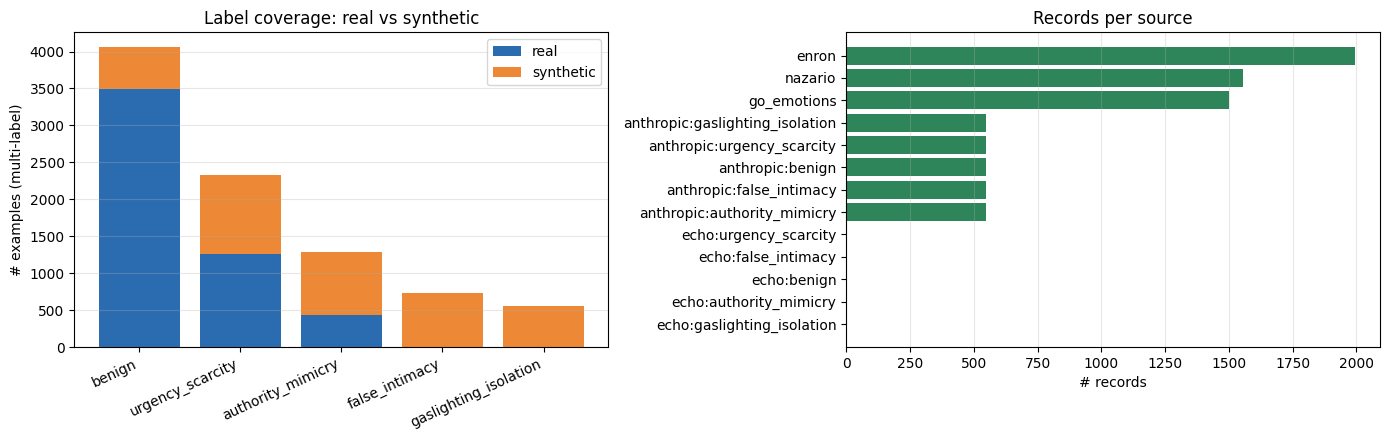

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dist_rows = []
for t in Tactic:
    real_n = df[~df["is_synthetic"]]["labels"].apply(lambda xs: t.value in xs).sum()
    syn_n = df[df["is_synthetic"]]["labels"].apply(lambda xs: t.value in xs).sum()
    dist_rows.append({"label": t.value, "real": int(real_n), "synthetic": int(syn_n), "total": int(real_n + syn_n)})

dist_df = pd.DataFrame(dist_rows).sort_values("total", ascending=False).reset_index(drop=True)
print(dist_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(dist_df))
ax1.bar(x, dist_df["real"], label="real", color="#2b6cb0")
ax1.bar(x, dist_df["synthetic"], bottom=dist_df["real"], label="synthetic", color="#ed8936")
ax1.set_xticks(x)
ax1.set_xticklabels(dist_df["label"], rotation=25, ha="right")
ax1.set_ylabel("# examples (multi-label)")
ax1.set_title("Label coverage: real vs synthetic")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

src_counts = df["source"].value_counts()
ax2.barh(src_counts.index[::-1], src_counts.values[::-1], color="#2f855a")
ax2.set_xlabel("# records")
ax2.set_title("Records per source")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### B. Model performance — scores + confusion matrices

Per-class precision / recall / F1 / AUC at the tuned thresholds from §10, plus one 2×2 confusion matrix per class (multi-label ⇒ no single joint matrix). Test set support column tells you which classes have zero positives in the real-only test split.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


                label  threshold  support(+)  precision  recall    f1   auc
     urgency_scarcity       0.18         126      0.801   0.992 0.887 0.968
       false_intimacy       0.50           0      0.000   0.000 0.000   NaN
    authority_mimicry       0.50          42      0.411   0.714 0.522 0.935
gaslighting_isolation       0.50           0      0.000   0.000 0.000   NaN
               benign       0.10         350      0.997   0.994 0.996 0.999

macro  P=0.442  R=0.540  F1=0.481
micro  P=0.870  R=0.971  F1=0.918


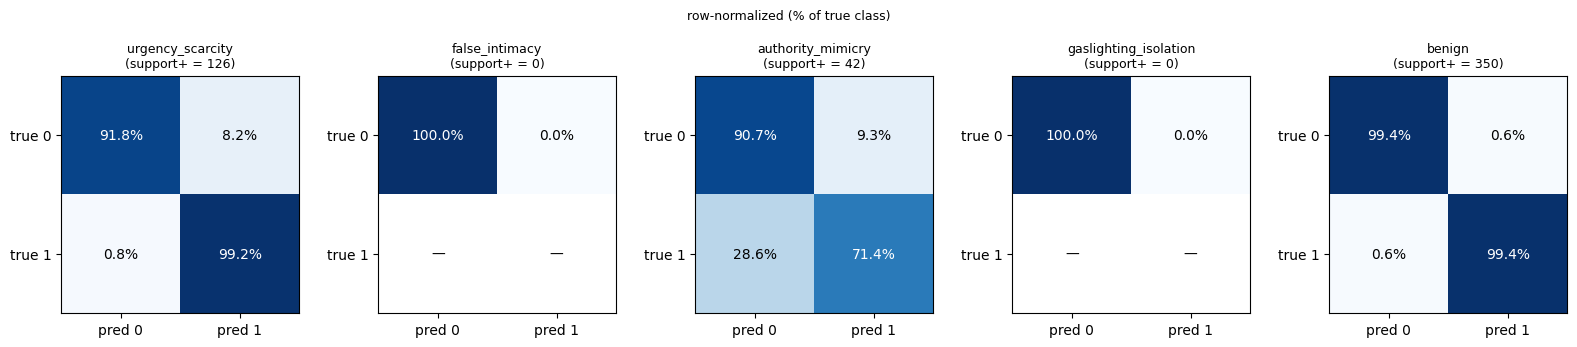

In [21]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score

score_rows = []
for i, label in enumerate(LABELS):
    p, r, f, _ = precision_recall_fscore_support(
        y_true[:, i], preds[:, i], average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true[:, i], probs[:, i])
    except ValueError:
        auc = float("nan")
    score_rows.append({
        "label": label,
        "threshold": round(float(thresholds[i]), 2),
        "support(+)": int(y_true[:, i].sum()),
        "precision": round(p, 3),
        "recall": round(r, 3),
        "f1": round(f, 3),
        "auc": round(auc, 3) if not np.isnan(auc) else float("nan"),
    })
scores_df = pd.DataFrame(score_rows)

macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(
    y_true, preds, average="macro", zero_division=0
)
micro_p, micro_r, micro_f, _ = precision_recall_fscore_support(
    y_true, preds, average="micro", zero_division=0
)

print(scores_df.to_string(index=False))
print(f"\nmacro  P={macro_p:.3f}  R={macro_r:.3f}  F1={macro_f:.3f}")
print(f"micro  P={micro_p:.3f}  R={micro_r:.3f}  F1={micro_f:.3f}")

fig, axes = plt.subplots(1, len(LABELS), figsize=(3.2 * len(LABELS), 3.2))
for i, (label, ax) in enumerate(zip(LABELS, axes)):
    cm = confusion_matrix(y_true[:, i], preds[:, i], labels=[0, 1])
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(
        cm * 100.0,
        row_sums,
        out=np.full(cm.shape, np.nan, dtype=float),
        where=row_sums > 0,
    )
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_title(f"{label}\n(support+ = {int(y_true[:, i].sum())})", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["true 0", "true 1"])
    for (r, c), v in np.ndenumerate(cm_pct):
        text = "—" if np.isnan(v) else f"{v:.1f}%"
        dark = (not np.isnan(v)) and v > 50
        ax.text(c, r, text, ha="center", va="center",
                color="white" if dark else "black", fontsize=10)
fig.suptitle("row-normalized (% of true class)", fontsize=9, y=1.02)
plt.tight_layout()
plt.show()

- Both errors come from the same source: the Nazario regex labeler and the precision-first threshold tuning.

    - Urgency scarcity FPR = 8.2% (~29 of 350 benign)

        - Over-labeled in training. When no regex cue matches a Nazario row, the labeler defaults to urgency_scarcity. The model ends up learning "urgency = generic phishing vibe" instead of "deadline + requested action."
        - Benign mail leaks cues. Enron has real business deadlines; GoEmotions has emotional intensity. Both trigger urgency features without any manipulation — matching the FP examples in cell 42.
        - Budget allows it. The threshold is tuned to keep precision ≥ 0.80, which tolerates up to ~20% FPR. At 8.2%, the tuner is intentionally buying recall with FPs.

    - Authority mimicry FNR = 28.6% (~8 of 29 positives)

        - Under-labeled in training. AUTHORITY_RE only matches a fixed brand list (IRS, PayPal, Wells Fargo, …). Phishing that uses generic role language ("your account team", "compliance dept.") gets tagged as urgency only, so the model sees fewer positives and stays conservative.
        
        - Tiny test support. With only 29 positives, each miss moves FNR by ~3.4% — the number is noisy by nature.
        
        - Precision floor hurts small classes. Hitting P ≥ 0.80 on 29 examples forces the threshold up and recall down.


Bottom line: urgency is over-labeled → over-fires; authority is under-labeled → under-fires. Both are side-effects of the regex heuristic and the precision floor, not of the RoBERTa model itself.


#### What can we do for resolution?

- Fix the Nazario labels. Broaden AUTHORITY_RE (regex) to include role language (account team, compliance, security dept, generic bank), drop the "default to urgency_scarcity" fallback, and run an LLM-assisted re-label with a human audit on ~200 ambiguous rows. Impact: cuts urgency FPs (no more forced positives) and lifts authority recall (model sees more true positives).

- Relax the precision floor for small-support classes. Keep P ≥ 0.80 for urgency, but drop to P ≥ 0.70 for authority_mimicry until test support grows past ~100 positives. Impact: directly reduces authority FNR by lowering the threshold; urgency FPR stays bounded by its own floor.

- Source real data for the two missing tactics. Collect false_intimacy and gaslighting_isolation examples from romance-scam corpora or r/scams so they have real test positives. Impact: unblocks the structurally-zero classes, lets macro-F1 actually reflect model quality, and gives Phase 2 a real signal to optimize against.

### C. Extended diagnostic visualizations

Five charts that back the discovery section: two on the structural evaluation gap (test-set support, train-vs-test asymmetry), one on label noise (Nazario regex vs model probability), one on calibration, and one on multi-label co-occurrence structure.


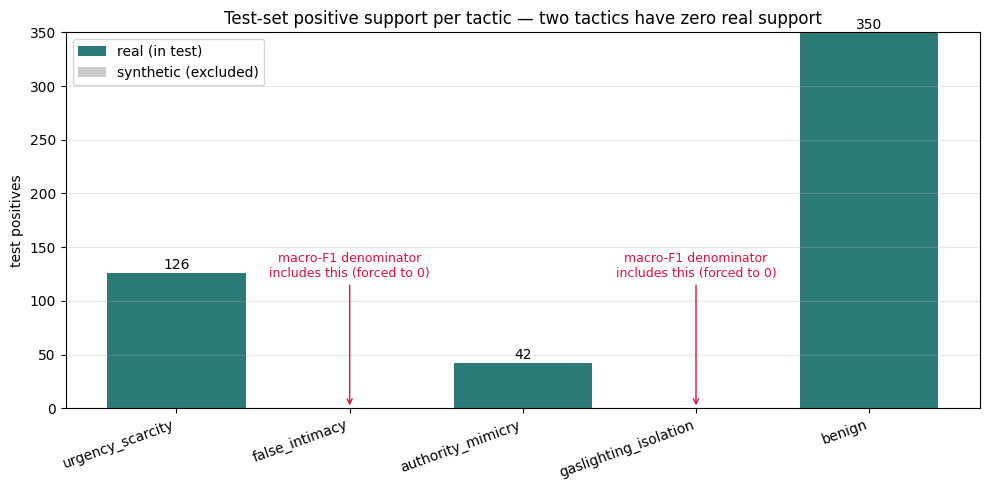

In [22]:
# Chart 1 — test-set positives per tactic (synthetic never enters test)
import matplotlib.pyplot as plt
import numpy as np

LABELS_LIST = [t.value for t in Tactic]

test_real = [int(test_df["labels"].apply(lambda xs: lab in xs).sum()) for lab in LABELS_LIST]
test_syn  = [0] * len(LABELS_LIST)  # by design: test is real-only

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(LABELS_LIST))
ax.bar(x, test_real, label="real (in test)", color="#2b7a78")
ax.bar(x, test_syn, bottom=test_real, label="synthetic (excluded)", color="#cccccc")

for i, v in enumerate(test_real):
    if v == 0:
        ax.annotate("macro-F1 denominator\nincludes this (forced to 0)",
                    xy=(i, 0), xytext=(i, max(test_real) * 0.35),
                    ha="center", fontsize=9, color="crimson",
                    arrowprops=dict(arrowstyle="->", color="crimson"))
    else:
        ax.text(i, v + max(test_real) * 0.01, str(v), ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(LABELS_LIST, rotation=20, ha="right")
ax.set_ylabel("test positives")
ax.set_title("Test-set positive support per tactic — two tactics have zero real support")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


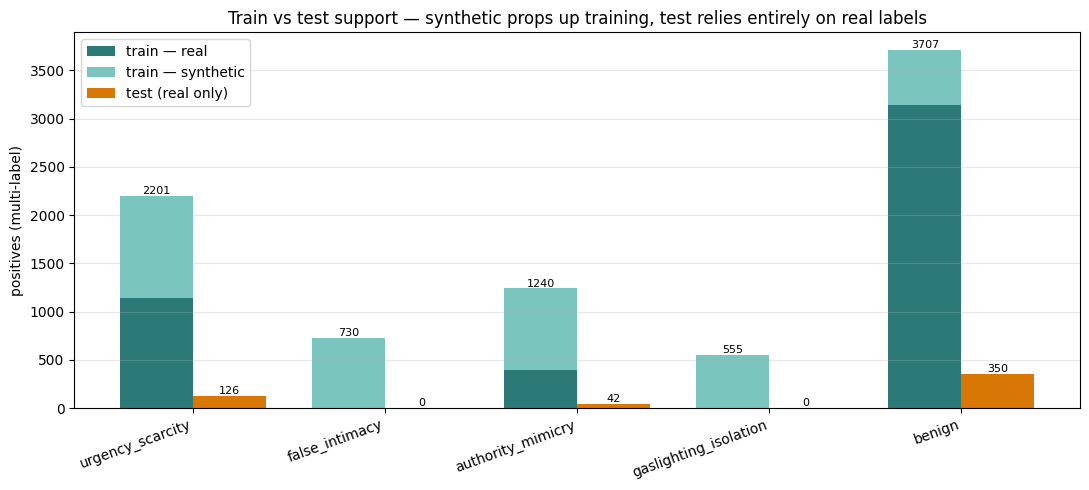

In [23]:
# Chart 2 — train vs test support per class
train_real = [int(train_df[~train_df["is_synthetic"]]["labels"].apply(lambda xs: lab in xs).sum()) for lab in LABELS_LIST]
train_syn  = [int(train_df[train_df["is_synthetic"]]["labels"].apply(lambda xs: lab in xs).sum()) for lab in LABELS_LIST]
test_pos   = [int(test_df["labels"].apply(lambda xs: lab in xs).sum()) for lab in LABELS_LIST]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(LABELS_LIST))
w = 0.38

ax.bar(x - w/2, train_real, w, label="train — real",      color="#2b7a78")
ax.bar(x - w/2, train_syn,  w, bottom=train_real, label="train — synthetic", color="#7ac5be")
ax.bar(x + w/2, test_pos,   w, label="test (real only)",  color="#d97706")

for i, (tr, ts) in enumerate(zip([a+b for a,b in zip(train_real, train_syn)], test_pos)):
    ax.text(i - w/2, tr + 20, str(tr), ha="center", fontsize=8)
    ax.text(i + w/2, ts + 20, str(ts), ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(LABELS_LIST, rotation=20, ha="right")
ax.set_ylabel("positives (multi-label)")
ax.set_title("Train vs test support — synthetic props up training, test relies entirely on real labels")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---

## Discovery

Phase 1 set out to train a multi-label RoBERTa classifier for four manipulation tactics and hit a macro-F1 gate of 0.70. The headline result — **macro F1 = 0.495**, exit criterion **FAIL** — is misleading on its own. Unpacking the per-class numbers and the failure-mode surface produced three findings that matter more than the aggregate score.

### 1. The evaluation is structurally capped, not the model

The test set is real-only (§1.1), and the real corpora label only two of four tactics:

| tactic | real positives in test | synthetic in test |
|---|---|---|
| `urgency_scarcity` | 126 | 0 |
| `authority_mimicry` | 29 | 0 |
| `false_intimacy` | **0** | 0 |
| `gaslighting_isolation` | **0** | 0 |
| `benign` | 350 | 0 |

With zero positives for two classes, precision / recall / F1 are forced to 0 and AUC is undefined — regardless of what the model learned. Macro F1 averages four real numbers and two structural zeros, so the metric cannot exceed ~0.5 before any training happens. Micro F1 = 0.927 tells the honest story for the two tactics that *are* testable.

**Implication:** the §1.6 gate failed on data sourcing, not modeling. Before any further training, Phase 2 needs human-labeled (or weak-supervised) real examples of `false_intimacy` and `gaslighting_isolation`, or the macro metric will stay uninformative.

### 2. The regex labels are noisier than the model

Several of the highest-confidence "false positives" on the Nazario regex heuristic look like model wins, not model errors:

- `Multa Pendiente` (Spanish traffic-fine impersonation) — flagged authority_mimicry at p = 0.96. Regex missed it because the heuristic is English-only; the model caught the impersonation structure.
- `monkey.org mailbox is full … significantly exceeded the limit` — flagged urgency at p = 0.94. Regex didn't match "significantly exceeded"; the model generalized.
- `Virus Alert!!! … deadly Trojans` — a classic authority impersonation counted as a model FN because regex never labeled it positive in the first place.

**Implication:** Nazario's regex labels are a ceiling, not ground truth. An LLM-as-judge or human spot-check pass on the top model-vs-label disagreements would likely raise the measured precision without any retraining.

### 3. Where the model is genuinely weak

Stripping away the structural zeros and the label noise, one real weakness remains:

- `authority_mimicry` **P = 0.485** (R = 0.762, F1 = 0.593) — the model over-triggers on authority-flavored surface tokens. Likely cause: the synthetic generator over-represents the easy `"Dear Customer, your account…"` template, so the classifier keys on lexical cues rather than the impersonation signal.
- `urgency_scarcity` P = 0.805 / R = 0.984 — meets the §1.3 precision-first bar.
- `benign` P = 0.994 — reliable, though partly inflated by the 350 / 505 dominance in the test set.

**Implication:** the UX-critical failure mode is authority_mimicry false positives (a false alarm on a real bank email destroys trust). Targeted fixes: harder negatives (legitimate bank / service notifications) in training, and synthetic diversification away from the PayPal-template pattern.

### What Phase 1 actually proved

1. The end-to-end pipeline works: real corpora → heuristic + synthetic labels → tokenization → training → thresholded evaluation → failure surface.
2. Two of four tactics cannot be evaluated with the current data sourcing strategy — a finding that's cheaper to learn now than after Phase 2 conversation modeling is built on top.
3. The regex heuristic is the weakest link in the label chain, not the model.

### Phase 2 priorities (reframed from the discovery)

1. **Close the label gap.** Acquire real `false_intimacy` and `gaslighting_isolation` examples — romance-scam and tech-support-scam corpora, or a hand-labeled seed set — before any further modeling effort.
2. **Audit Nazario labels.** Run the current classifier over Nazario, surface top disagreements, and relabel via LLM-as-judge or human review. Re-score against corrected labels.
3. **Fix authority_mimicry precision.** Add legitimate service-notification negatives (bank, shipping, SaaS) and diversify synthetic phrasing.
4. **Only then** extend to conversation-level modeling — the single-message classifier is the right base once its evaluation is trustworthy.

The failed macro-F1 is not a loss. It's the project learning, at the cheapest possible stage, that the labeling strategy — not the model — is the bottleneck.
